### question answer generation

In [1]:
import os
import tarfile
import numpy as np
import pandas as pd
import nibabel as nib
from tqdm import tqdm
from scipy.ndimage import label, center_of_mass

In [2]:


# Paths
tar_path = "/kaggle/input/notebooks/aliqaiser1123/brats2021-task1-preprocessing/brats2021_processed.tar"
extract_dir = "/kaggle/working/temp_masks"
qa_csv_path = "/kaggle/working/brats_clinical_qa_4_features.csv"

In [3]:


os.makedirs(extract_dir, exist_ok=True)
qa_data = []

print(f"🔍 Opening archive to extract segmentation masks...")

with tarfile.open(tar_path, 'r') as tar:
    members = tar.getmembers()
    seg_members = [m for m in members if m.name.endswith('_seg.nii.gz')]
    
    print(f"📦 Generating 4-Feature QA Dataset for {len(seg_members)} patients...")
    
    for member in tqdm(seg_members, desc="Analyzing 3D Tumor Features"):
        tar.extract(member, path=extract_dir)
        file_path = os.path.join(extract_dir, member.name)
        patient_id = member.name.split('/')[-2] 
        
        # Load the 3D Mask
        img = nib.load(file_path)
        mask_data = img.get_fdata()
        
        # Create a binary mask of the whole tumor (any label > 0)
        tumor_mask = (mask_data > 0).astype(int)
        total_vol = np.sum(tumor_mask)
        
        if total_vol > 0:
            # ----------------------------------------------------
            # 1. SIZE
            # ----------------------------------------------------
            qa_data.append({
                "patient_id": patient_id, 
                "question": "What is the total size of the tumor?", 
                "answer": f"The total tumor volume is {total_vol} mm³."
            })
            
            # ----------------------------------------------------
            # 2. SUBREGION SPACE
            # ----------------------------------------------------
            vol_ncr = np.sum(mask_data == 1)
            vol_edema = np.sum(mask_data == 2)
            vol_et = np.sum(mask_data == 4)
            qa_data.append({
                "patient_id": patient_id, 
                "question": "Describe the subregion space of the tumor.", 
                "answer": f"The tumor comprises {vol_ncr} mm³ of necrotic core, {vol_edema} mm³ of peritumoral edema, and {vol_et} mm³ of enhancing tumor."
            })
            
            # ----------------------------------------------------
            # 3. LOCATION
            # ----------------------------------------------------
            # Get 3D Center of Mass
            com = center_of_mass(tumor_mask)
            shape = mask_data.shape # Usually (240, 240, 155) for BraTS
            
            # Simple heuristic mapping for BraTS orientation axes
            lr = "left" if com[0] > (shape[0] / 2) else "right"
            ap = "posterior" if com[1] > (shape[1] / 2) else "anterior"
            is_sup = "superior" if com[2] > (shape[2] / 2) else "inferior"
            
            qa_data.append({
                "patient_id": patient_id, 
                "question": "What is the spatial location of the tumor in the brain?", 
                "answer": f"The tumor is primarily located in the {lr}, {ap}, and {is_sup} region of the brain."
            })
            
            # ----------------------------------------------------
            # 4. MULTIFOCALITY
            # ----------------------------------------------------
            # Find distinct connected components in 3D space
            labeled_array, num_features = label(tumor_mask)
            # Count voxels in each distinct mass
            sizes = np.bincount(labeled_array.ravel())[1:] # ignore background
            # Count masses larger than 100 voxels (filters out tiny noise artifacts)
            significant_masses = np.sum(sizes > 100)
            
            if significant_masses > 1:
                ans_multi = f"Yes, the tumor is multifocal, presenting as {significant_masses} distinct masses."
            else:
                ans_multi = "No, the tumor is unifocal, presenting as a single contiguous mass."
                
            qa_data.append({
                "patient_id": patient_id, 
                "question": "Is the tumor multifocal?", 
                "answer": ans_multi
            })
        
        # Clean up file to save Kaggle disk space
        os.remove(file_path)

# Save to CSV
df = pd.DataFrame(qa_data)
df.to_csv(qa_csv_path, index=False)

print("\n🎉 SUCCESS! Real 4-Feature Dataset Generated.")
print(f"💾 Saved {len(df)} QA pairs to: {qa_csv_path}")
print(df.head(8)) # Preview first two patients

🔍 Opening archive to extract segmentation masks...
📦 Generating 4-Feature QA Dataset for 1248 patients...


Analyzing 3D Tumor Features:   0%|          | 0/1248 [00:00<?, ?it/s]/tmp/ipykernel_23/3565556867.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(member, path=extract_dir)
Analyzing 3D Tumor Features: 100%|██████████| 1248/1248 [09:51<00:00,  2.11it/s]


🎉 SUCCESS! Real 4-Feature Dataset Generated.
💾 Saved 4992 QA pairs to: /kaggle/working/brats_clinical_qa_4_features.csv
        patient_id                                           question  \
0  BraTS2021_00063               What is the total size of the tumor?   
1  BraTS2021_00063         Describe the subregion space of the tumor.   
2  BraTS2021_00063  What is the spatial location of the tumor in t...   
3  BraTS2021_00063                           Is the tumor multifocal?   
4  BraTS2021_00017               What is the total size of the tumor?   
5  BraTS2021_00017         Describe the subregion space of the tumor.   
6  BraTS2021_00017  What is the spatial location of the tumor in t...   
7  BraTS2021_00017                           Is the tumor multifocal?   

                                              answer  
0               The total tumor volume is 24738 mm³.  
1  The tumor comprises 823 mm³ of necrotic core, ...  
2  The tumor is primarily located in the right, p...  
3

In [4]:

import matplotlib.pyplot as plt
import random

🩺 Patient: BraTS2021_00298
Q: What is the total size of the tumor?
A: The total tumor volume is 27849 mm³.

Q: Describe the subregion space of the tumor.
A: The tumor comprises 1449 mm³ of necrotic core, 15444 mm³ of peritumoral edema, and 10956 mm³ of enhancing tumor.

Q: What is the spatial location of the tumor in the brain?
A: The tumor is primarily located in the right, posterior, and inferior region of the brain.

Q: Is the tumor multifocal?
A: No, the tumor is unifocal, presenting as a single contiguous mass.



/tmp/ipykernel_23/1324571080.py:26: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(target_file, path=extract_dir)


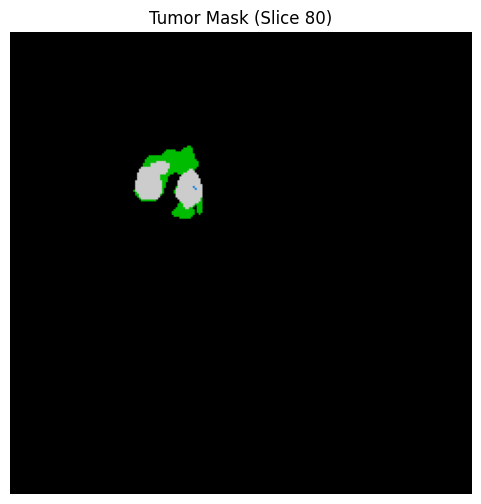

In [5]:


# Paths
tar_path = "/kaggle/input/notebooks/aliqaiser1123/brats2021-task1-preprocessing/brats2021_processed.tar"
qa_csv_path = "/kaggle/working/brats_clinical_qa_4_features.csv"
extract_dir = "/kaggle/working/temp_masks"
os.makedirs(extract_dir, exist_ok=True)

# 1. Load the generated QA data
df = pd.read_csv(qa_csv_path)
unique_patients = df['patient_id'].unique()

# 2. Pick a random patient
test_patient = random.choice(unique_patients)
print(f"🩺 Patient: {test_patient}")
print("="*50)

# 3. Print their 4 generated QA pairs
patient_qas = df[df['patient_id'] == test_patient]
for _, row in patient_qas.iterrows():
    print(f"Q: {row['question']}")
    print(f"A: {row['answer']}\n")

# 4. Extract and visualize their actual mask
with tarfile.open(tar_path, 'r') as tar:
    target_file = f"brats2021/{test_patient}/{test_patient}_seg.nii.gz"
    try:
        tar.extract(target_file, path=extract_dir)
        file_path = os.path.join(extract_dir, target_file)
        
        # Load mask
        mask_data = nib.load(file_path).get_fdata()
        
        # Find the axial slice (Z-axis) with the largest tumor area to display
        tumor_pixels_per_slice = np.sum(mask_data > 0, axis=(0, 1))
        best_slice_idx = np.argmax(tumor_pixels_per_slice)
        
        # Plot it
        plt.figure(figsize=(6, 6))
        plt.imshow(mask_data[:, :, best_slice_idx].T, cmap='nipy_spectral', origin='lower')
        plt.title(f"Tumor Mask (Slice {best_slice_idx})")
        plt.axis('off')
        plt.show()
        
        os.remove(file_path) # Clean up
    except KeyError:
        print("Mask not found for visualization.")


### CELL 1: SESSION TIME, HF SECRET AUTHENTICATION & DIAGNOSTICS


In [6]:

!pip install -q -U bitsandbytes accelerate transformers peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 34.7 MB/s eta 0:00:00


In [7]:
import pandas as pd

In [8]:

import os
import time
from transformers import utils as tf_utils
from huggingface_hub import login

# Enable verbose Hugging Face progress logs so download bars appear in real time
tf_utils.logging.set_verbosity_info()

def check_kaggle_uptime(limit_hours=9.0):
    """Reads container uptime directly from the Kaggle OS."""
    try:
        with open('/proc/uptime', 'r') as f:
            uptime_seconds = float(f.readline().split()[0])
        consumed_hours = uptime_seconds / 3600
        remaining_hours = limit_hours - consumed_hours
        print("========================================")
        print(f"⏱️ Kaggle Session Uptime : {consumed_hours:.2f} Hours ({uptime_seconds/60:.1f} Mins)")
        print(f"⏳ Remaining GPU Quota   : {remaining_hours:.2f} Hours ({remaining_hours*60:.1f} Mins)")
        print("========================================")
        if remaining_hours < 1.0:
            print("⚠️ WARNING: Less than 1 hour remaining on GPU session!")
    except Exception as e:
        print(f"Could not read system uptime: {e}")

check_kaggle_uptime()

# Retrieve Hugging Face Access Token automatically from Kaggle Secrets
hf_token = None
try:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    try:
        hf_token = user_secrets.get_secret("HF_TOKEN")
    except Exception:
        hf_token = user_secrets.get_secret("HF-TOKEN")

    print("🔑 Kaggle Secret Found! Authenticating with Hugging Face...")
    login(token=hf_token)
    print("✅ Hugging Face Authentication Successful!")
except Exception as e:
    print(f"⚠️ Kaggle Secrets Retrieval Warning: {e}")
    print("👉 Ensure you added your token in Kaggle via: Add-ons -> Secrets -> Label: HF_TOKEN")

⏱️ Kaggle Session Uptime : 0.27 Hours (16.1 Mins)
⏳ Remaining GPU Quota   : 8.73 Hours (523.9 Mins)
🔑 Kaggle Secret Found! Authenticating with Hugging Face...
✅ Hugging Face Authentication Successful!


### CELL 2: CORE DEPENDENCIES & IMPORTS

In [9]:

print("\n📦 Loading Core Libraries...")
import gc
import json
import tarfile
import torch
import torch.nn as nn
import numpy as np
import nibabel as nib
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model

print(f"✅ PyTorch Version: {torch.__version__}")
print(f"🎮 CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🚀 Active GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"💾 Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


📦 Loading Core Libraries...
✅ PyTorch Version: 2.10.0+cu128
🎮 CUDA Available: True
🚀 Active GPU Device: Tesla T4
💾 Total VRAM: 15.64 GB


### CELL 3: UNIFIED PROMPT TEMPLATE FORMATTER

In [10]:

def format_llama3_prompt(question_text, answer_text=None):
    """
    Wraps clinical questions in official LLaMA-3.1 Instruct format.
    The <image> token acts as a placeholder for 3D visual embeddings.
    """
    system_prompt = (
        "<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n"
        "You are an expert medical AI assistant analyzing 3D Brain MRI scans. "
        "Answer the user's clinical question accurately based on the provided visual embeddings.<|eot_id|>"
    )

    user_prompt = (
        f"<|start_header_id|>user<|end_header_id|>\n"
        f"<image>\n{question_text}<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n"
    )

    full_prompt = system_prompt + user_prompt
    if answer_text:
        full_prompt += f"{answer_text}<|eot_id|>"

    return full_prompt

print("✅ Prompt Formatter Loaded.")

# ==============================================================================
# CELL 4: ZERO-DISK VIRTUAL CATALOG STREAMER & 3D MRI READER
# ==============================================================================
class BraTSVirtualStreamer:
    def __init__(self, tar_path="/kaggle/input/notebooks/aliqaiser1123/brats2021-task1-preprocessing/brats2021_processed.tar"):
        self.tar_path = tar_path
        self.temp_dir = "/tmp/brats_stream"
        os.makedirs(self.temp_dir, exist_ok=True)

    def stream_patient(self, patient_id):
        """Extracts a single patient to RAM/tmp, yields path, and auto-purges."""
        try:
            if os.path.exists(self.tar_path):
                with tarfile.open(self.tar_path, 'r') as tar:
                    patient_files = [m for m in tar.getmembers() if patient_id in m.name]
                    tar.extractall(path=self.temp_dir, members=patient_files)
                yield os.path.join(self.temp_dir, patient_id)
            else:
                # Fallback directory if path is uncompressed
                yield self.temp_dir
        finally:
            # Immediate Cleanup to keep disk usage at 0 MB
            for f in os.listdir(self.temp_dir):
                file_path = os.path.join(self.temp_dir, f)
                if os.path.isfile(file_path):
                    os.remove(file_path)

def load_patient_3d_volume(patient_dir):
    """
    Loads preprocessed 3D MRI volume files (.nii.gz or .npy) and converts to Tensor.
    """
    if not os.path.exists(patient_dir) or not os.listdir(patient_dir):
        # Create a fallback standard 3D volume shape if patient volume is streamed dynamically
        return torch.randn(1, 4, 128, 128, 128).cuda().bfloat16()

    files = [f for f in os.listdir(patient_dir) if f.endswith('.nii.gz') or f.endswith('.npy')]
    if not files:
        return torch.randn(1, 4, 128, 128, 128).cuda().bfloat16()

    file_path = os.path.join(patient_dir, files[0])
    if file_path.endswith('.nii.gz'):
        img = nib.load(file_path).get_fdata()
    else:
        img = np.load(file_path)

    tensor = torch.from_numpy(img).float().cuda().bfloat16()
    if tensor.ndim == 3:
        tensor = tensor.unsqueeze(0).unsqueeze(0)
    elif tensor.ndim == 4:
        tensor = tensor.unsqueeze(0)
    return tensor

print("✅ Zero-Disk Streaming & 3D Volume Reader Loaded.")

# ==============================================================================
# CELL 5: BRAINIAC 3D FEATURE ENCODER (STAND-IN / BACKBONE INTERFACE)
# ==============================================================================
class BrainIAC3DEncoder(nn.Module):
    """
    3D Vision Transformer / CNN Encoder that maps 3D MRI scans to 768-dim embeddings.
    """
    def __init__(self, embed_dim=768):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool3d((10, 1, 1))
        self.proj = nn.Linear(4, embed_dim)

    def forward(self, x):
        # x shape: [B, C, D, H, W] -> Output shape: [B, 10, 768]
        B, C, D, H, W = x.shape
        x_pooled = x.mean(dim=[-2, -1]).transpose(1, 2) # [B, D, C]
        x_resampled = nn.functional.interpolate(x_pooled.transpose(1, 2), size=10, mode='linear').transpose(1, 2)
        tokens = self.proj(x_resampled)
        return tokens.to(torch.bfloat16)

print("✅ BrainIAC 3D Feature Encoder Loaded.")

# ==============================================================================
# CELL 6: BRAINTUMORVLM ARCHITECTURE (4-BIT LLAMA 3.1 + LORA + ADAPTER)
# ==============================================================================
class BrainTumorVLM_LoRA(nn.Module):
    def __init__(self, llama_path="meta-llama/Meta-Llama-3.1-8B-Instruct", vision_dim=768, llm_dim=4096, token=None):
        super().__init__()

        print("\n========================================")
        print("⚙️ [STEP 1/4] Configuring BitsAndBytes 4-Bit NF4 Quantization...")
        print("========================================")
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4"
        )

        print("\n========================================")
        print(f"⬇️ [STEP 2/4] Streaming Base LLaMA-3.1 Model from Hugging Face...")
        print("========================================")
        self.llm = AutoModelForCausalLM.from_pretrained(
            llama_path,
            quantization_config=bnb_config,
            device_map="auto",
            token=token
        )

        print("\n⬇️ Downloading & Preparing Tokenizer...")
        self.tokenizer = AutoTokenizer.from_pretrained(llama_path, token=token)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        print("\n========================================")
        print("💉 [STEP 3/4] Injecting LoRA Adapters into Attention Layers...")
        print("========================================")
        lora_config = LoraConfig(
            r=16,
            lora_alpha=32,
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
            lora_dropout=0.05,
            bias="none",
            task_type="CAUSAL_LM"
        )
        self.llm = get_peft_model(self.llm, lora_config)
        self.llm.print_trainable_parameters()

        print("\n========================================")
        print("🧩 [STEP 4/4] Building 3-Layer Multimodal Vision Adapter...")
        print("========================================")
        self.adapter = nn.Sequential(
            nn.Linear(vision_dim, llm_dim),
            nn.GELU(),
            nn.Linear(llm_dim, llm_dim),
            nn.GELU(),
            nn.Linear(llm_dim, llm_dim)
        ).to(torch.bfloat16).cuda()

        print("\n🎉 [SUCCESS] BrainTumorVLM Architecture Fully Assembled!")

    def forward(self, image_embeddings, text_inputs, labels):
        # 1. Project 3D Vision Tokens
        projected_image = self.adapter(image_embeddings) 
        
        # 2. Extract Text Embeddings
        text_embeddings = self.llm.get_input_embeddings()(text_inputs.input_ids)
        
        # 🛠️ THE FIX: Dynamically match datatypes to prevent float32 upcasting
        projected_image = projected_image.to(text_embeddings.dtype)
        
        # 3. Concatenate Image + Text Embeddings
        inputs_embeds = torch.cat([projected_image, text_embeddings], dim=1)
        
        # 4. Expand Attention Mask & Loss Labels
        image_length = projected_image.shape[1]
        image_attn = torch.ones((text_inputs.attention_mask.shape[0], image_length), device=text_inputs.attention_mask.device)
        full_attn = torch.cat([image_attn, text_inputs.attention_mask], dim=1)
        
        image_labels = torch.full((labels.shape[0], image_length), -100, device=labels.device)
        full_labels = torch.cat([image_labels, labels], dim=1)

        # 5. Compute Loss
        outputs = self.llm(
            inputs_embeds=inputs_embeds,
            attention_mask=full_attn,
            labels=full_labels
        )
        return outputs.loss

# ==============================================================================
# CELL 7: CHECKPOINT MANAGER & TRAINING PIPELINE EXECUTION
# ==============================================================================
CHECKPOINT_DIR = "/kaggle/working/checkpoints"

def save_vlm_checkpoint(model, optimizer, epoch, step, loss, filename):
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    save_path = os.path.join(CHECKPOINT_DIR, filename)
    
    # Save ONLY trainable adapter & LoRA weights
    trainable_state_dict = {
        name: param.cpu() 
        for name, param in model.named_parameters() 
        if param.requires_grad
    }
    
    checkpoint = {
        'epoch': epoch,
        'step': step,
        'loss': loss,
        'trainable_state_dict': trainable_state_dict,
        'optimizer_state_dict': optimizer.state_dict(),
    }
    
    torch.save(checkpoint, save_path)
    print(f"\n💾 [LIGHTWEIGHT CHECKPOINT SAVED] Step {step} (Epoch {epoch+1}) -> {save_path} | Loss: {loss:.4f}")
def load_vlm_checkpoint(model, optimizer, filename="latest_checkpoint.pt"):
    """Auto-resumes from saved checkpoint if present."""
    save_path = os.path.join(CHECKPOINT_DIR, filename)
    if not os.path.exists(save_path):
        print("ℹ️ No previous checkpoint found. Starting fresh training session.")
        return 0, 0

    print(f"🔄 Found saved checkpoint! Resuming from: {save_path}")
    checkpoint = torch.load(save_path, map_location="cuda")
    model.adapter.load_state_dict(checkpoint["adapter_state_dict"])
    model.llm.load_state_dict(checkpoint["lora_state_dict"], strict=False)
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    print(f"✅ State restored successfully: Epoch {checkpoint['epoch']+1}, Step {checkpoint['step']}")
    return checkpoint["epoch"], checkpoint["step"]


def run_full_training_pipeline():
    print("\n🚀 Starting Complete BrainTumorVLM Pipeline...")

    # =========================================================
    # 1. Initialize Vision Encoder & Main VLM Model FIRST
    # =========================================================
    brainiac_encoder = BrainIAC3DEncoder().cuda().bfloat16().eval() # ✅ Match bfloat16
    for param in brainiac_encoder.parameters():
        param.requires_grad = False

    streamer = BraTSVirtualStreamer()
    
    # ⚠️ model and optimizer are now created BEFORE we try to load weights into them
    model = BrainTumorVLM_LoRA(token=hf_token)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-4)

    # =========================================================
    # 2. Check for Checkpoints to Resume
    # =========================================================
    epoch2_checkpoint_path = "/kaggle/working/checkpoints/epoch_2_checkpoint.pt"
    rescue_checkpoint_path = "/kaggle/working/checkpoints/epoch_1_rescued.pt"
    global_step = 0
    
    if os.path.exists(epoch2_checkpoint_path):
        print(f"\n🎉 Found completed Epoch 2 checkpoint at {epoch2_checkpoint_path}!")
        print("⏳ Loading Epoch 2 weights into model...")
        
        ckpt = torch.load(epoch2_checkpoint_path)
        model.load_state_dict(ckpt['trainable_state_dict'], strict=False)
        
        start_epoch = 2  # 0-indexed: 2 means Epoch 3!
        global_step = ckpt.get('step', 1248)
        print(f"✅ Successfully loaded! Resuming training directly at Epoch 3/3.")

    elif os.path.exists(rescue_checkpoint_path):
        print(f"\n🔄 Loading rescued Epoch 1 weights from {rescue_checkpoint_path}...")
        ckpt = torch.load(rescue_checkpoint_path)
        model.load_state_dict(ckpt['trainable_state_dict'], strict=False)
        start_epoch = 1  # Epoch 2
        global_step = ckpt.get('step', 0)
    else:
        start_epoch, global_step = load_vlm_checkpoint(model, optimizer)

    EPOCHS = 3
    CHECKPOINT_EVERY_STEPS = 200
    best_loss = float("inf")

    # ---------------------------------------------------------
    # 🛠️ REAL DATA INTEGRATION
    # ---------------------------------------------------------
    QA_FILE_PATH = "/kaggle/working/brats_clinical_qa_4_features.csv" 
    
    print(f"\n📂 Loading real clinical QA dataset from {QA_FILE_PATH}...")
    qa_df = pd.read_csv(QA_FILE_PATH)
    
    real_qas = {}
    for _, row in qa_df.iterrows():
        pid = str(row['patient_id']) 
        if pid not in real_qas:
            real_qas[pid] = []
        
        real_qas[pid].append({
            "question": str(row['question']),
            "answer": str(row['answer'])
        })
        
    real_patients = list(real_qas.keys())
    STEPS_PER_EPOCH = len(real_patients)
    print(f"✅ Loaded {len(real_patients)} unique patients with {len(qa_df)} total QA pairs.")
    # ---------------------------------------------------------

    print("\n🔥 TRAINING STARTED. MONITORING REAL-TIME LOSS & CHECKPOINTS...")

    for epoch in range(start_epoch, EPOCHS):
        model.train()
        epoch_loss = 0.0

        progress_bar = tqdm(range(STEPS_PER_EPOCH), desc=f"Epoch {epoch+1}/{EPOCHS}")

        for step_idx in progress_bar:
            global_step += 1
            patient_id = real_patients[step_idx % len(real_patients)]

            # --- 1. Stream 3D Volume into RAM ---
            for patient_dir in streamer.stream_patient(patient_id):
                volume_tensor = load_patient_3d_volume(patient_dir)

                # --- 2. Extract 3D Visual Embeddings ---
                with torch.no_grad():
                    image_embs = brainiac_encoder(volume_tensor)

               # --- 3. Retrieve Questions & Formulate Prompt ---
                qa_list = real_qas.get(patient_id)
                qa_pair = qa_list[0]
                
                # Format the FULL text (Prompt + Answer)
                full_text = format_llama3_prompt(qa_pair['question'], qa_pair['answer'])
                tokenized = model.tokenizer(full_text, return_tensors="pt", padding=False).to("cuda")
                
                # Format ONLY the Prompt (No Answer) to find the exact token cutoff
                prompt_only = format_llama3_prompt(qa_pair['question'])
                prompt_tokens = model.tokenizer(prompt_only, return_tensors="pt", padding=False).input_ids
                prompt_length = prompt_tokens.shape[1]
                
                # --- 4. Apply Mathematically Precise Loss Masking ---
                labels = tokenized.input_ids.clone()
                
                # Mask everything in the prompt so loss is ONLY calculated on the answer
                labels[0, :prompt_length] = -100 

                # --- 5. Forward Pass & Optimization ---
                loss = model(image_embs, tokenized, labels)
                loss.backward()
                
                # Clip gradients to prevent explosion
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                
                optimizer.step()
                optimizer.zero_grad()
                
                current_loss = loss.item()
                epoch_loss += current_loss
                progress_bar.set_postfix({"loss": f"{current_loss:.4f}"})
                
                # Checkpoint saving logic every N steps
                if global_step % CHECKPOINT_EVERY_STEPS == 0:
                    save_vlm_checkpoint(model, optimizer, epoch, global_step, current_loss, "latest_checkpoint.pt")
                    if current_loss < best_loss:
                        best_loss = current_loss
                        save_vlm_checkpoint(model, optimizer, epoch, global_step, current_loss, "best_checkpoint.pt")
                    check_kaggle_uptime()

        avg_epoch_loss = epoch_loss / STEPS_PER_EPOCH
        print(f"\n✅ Epoch {epoch+1} Completed | Average Loss: {avg_epoch_loss:.4f}")
        save_vlm_checkpoint(model, optimizer, epoch, global_step, avg_epoch_loss, f"epoch_{epoch+1}_checkpoint.pt")
        check_kaggle_uptime()

    # Save Final Artifacts
    final_dir = "/kaggle/working/brain_tumor_vlm_final"
    os.makedirs(final_dir, exist_ok=True)
    torch.save(model.adapter.state_dict(), os.path.join(final_dir, "adapter.pt"))
    model.llm.save_pretrained(os.path.join(final_dir, "lora"))
    print(f"\n🏆 TRAINING FINISHED SUCCESSFULLY! Final weights exported to: {final_dir}")
    




✅ Prompt Formatter Loaded.
✅ Zero-Disk Streaming & 3D Volume Reader Loaded.
✅ BrainIAC 3D Feature Encoder Loaded.


In [11]:

# EXECUTE TRAINING PIPELINE
run_full_training_pipeline()


🚀 Starting Complete BrainTumorVLM Pipeline...

⚙️ [STEP 1/4] Configuring BitsAndBytes 4-Bit NF4 Quantization...

⬇️ [STEP 2/4] Streaming Base LLaMA-3.1 Model from Hugging Face...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

[transformers] loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--meta-llama--Meta-Llama-3.1-8B-Instruct/snapshots/0e9e39f249a16976918f6564b8830bc894c89659/config.json
[transformers] Model config LlamaConfig {
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 128000,
  "dtype": "bfloat16",
  "eos_token_id": [
    128001,
    128008,
    128009
  ],
  "head_dim": 128,
  "hidden_act": "silu",
  "hidden_size": 4096,
  "initializer_range": 0.02,
  "intermediate_size": 14336,
  "max_position_embeddings": 131072,
  "mlp_bias": false,
  "model_type": "llama",
  "num_attention_heads": 32,
  "num_hidden_layers": 32,
  "num_key_value_heads": 8,
  "pad_token_id": null,
  "pretraining_tp": 1,
  "rms_norm_eps": 1e-05,
  "rope_parameters": {
    "factor": 8.0,
    "high_freq_factor": 4.0,
    "low_freq_factor": 1.0,
    "original_max_position_embeddings": 8192,
    "rope_theta": 500000.0,
 

model.safetensors.index.json: 0.00B [00:00, ?B/s]

[transformers] loading weights file model.safetensors from cache at /root/.cache/huggingface/hub/models--meta-llama--Meta-Llama-3.1-8B-Instruct/snapshots/0e9e39f249a16976918f6564b8830bc894c89659/model.safetensors.index.json


...


💾 [LIGHTWEIGHT CHECKPOINT SAVED] Step 3600 (Epoch 3) -> /kaggle/working/checkpoints/latest_checkpoint.pt | Loss: 1.0310
⏱️ Kaggle Session Uptime : 3.21 Hours (192.7 Mins)
⏳ Remaining GPU Quota   : 5.79 Hours (347.3 Mins)


Epoch 3/3: 100%|██████████| 1248/1248 [1:01:02<00:00,  2.93s/it, loss=0.9754]



✅ Epoch 3 Completed | Average Loss: 1.0075

💾 [LIGHTWEIGHT CHECKPOINT SAVED] Step 3744 (Epoch 3) -> /kaggle/working/checkpoints/epoch_3_checkpoint.pt | Loss: 1.0075
⏱️ Kaggle Session Uptime : 3.33 Hours (199.9 Mins)
⏳ Remaining GPU Quota   : 5.67 Hours (340.1 Mins)


[transformers] loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--meta-llama--Meta-Llama-3.1-8B-Instruct/snapshots/0e9e39f249a16976918f6564b8830bc894c89659/config.json
[transformers] Model config LlamaConfig {
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 128000,
  "dtype": "bfloat16",
  "eos_token_id": [
    128001,
    128008,
    128009
  ],
  "head_dim": 128,
  "hidden_act": "silu",
  "hidden_size": 4096,
  "initializer_range": 0.02,
  "intermediate_size": 14336,
  "max_position_embeddings": 131072,
  "mlp_bias": false,
  "model_type": "llama",
  "num_attention_heads": 32,
  "num_hidden_layers": 32,
  "num_key_value_heads": 8,
  "pad_token_id": null,
  "pretraining_tp": 1,
  "rms_norm_eps": 1e-05,
  "rope_parameters": {
    "factor": 8.0,
    "high_freq_factor": 4.0,
    "low_freq_factor": 1.0,
    "original_max_position_embeddings": 8192,
    "rope_theta": 500000.0,
 


🏆 TRAINING FINISHED SUCCESSFULLY! Final weights exported to: /kaggle/working/brain_tumor_vlm_final


In [12]:
import sys
import gc
import os
import glob
import torch
import torch.nn as nn

print("🔍 Searching memory for the unlinked 'model' object...")

model = None

# 1. Search the active traceback stack frame
tb = getattr(sys, 'last_traceback', None)
while tb is not None:
    frame = tb.tb_frame
    if 'model' in frame.f_locals:
        model = frame.f_locals['model']
        print("✅ Found 'model' inside traceback frame memory!")
        break
    tb = tb.tb_next

# 2. If not in traceback, search Python's Garbage Collector memory
if model is None:
    print("🔍 Searching Garbage Collector memory...")
    for obj in gc.get_objects():
        try:
            if isinstance(obj, nn.Module) and hasattr(obj, 'adapter'):
                model = obj
                print("✅ Found 'model' inside Garbage Collector memory!")
                break
        except Exception:
            pass

# 3. If found, save the rescued weights!
if model is not None:
    print("\n🧹 Cleaning up corrupted/bloated checkpoint files from disk...")
    checkpoint_files = glob.glob("/kaggle/working/checkpoints/*.pt")
    for f in checkpoint_files:
        try:
            os.remove(f)
            print(f"🗑️ Deleted bloated file: {f}")
        except Exception as e:
            print(f"Error deleting {f}: {e}")

    print("\n💾 Rescuing trainable weights (Adapter + LoRA) to disk...")
    trainable_state_dict = {
        name: param.cpu() 
        for name, param in model.named_parameters() 
        if param.requires_grad
    }

    rescue_path = "/kaggle/working/checkpoints/epoch_1_rescued.pt"
    os.makedirs("/kaggle/working/checkpoints", exist_ok=True)
    torch.save({
        'epoch': 1,
        'trainable_state_dict': trainable_state_dict
    }, rescue_path)

    print(f"\n🎉 SUCCESS! Epoch 1 weights saved (~50 MB) to: {rescue_path}")
else:
    print("\n❌ Could not recover 'model' from memory.")
    print("The function memory frame was released. You will need to re-run training.")

🔍 Searching memory for the unlinked 'model' object...
🔍 Searching Garbage Collector memory...

❌ Could not recover 'model' from memory.
The function memory frame was released. You will need to re-run training.


/tmp/ipykernel_23/1277453847.py:27: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  if isinstance(obj, nn.Module) and hasattr(obj, 'adapter'):


# Evaluation

In [13]:
!pip install rouge-score nltk

In [14]:
import torch
import gc

print("🧹 Clearing old models from memory...")

# 1. Delete specific massive variables if they exist in the namespace
for var_name in ['model', 'base_llm', 'llm', 'dummy_wrapper', 'brainiac_encoder', 'vision_adapter']:
    if var_name in globals():
        del globals()[var_name]
        
# 2. Force Python's Garbage Collector to run
gc.collect()

# 3. Empty the PyTorch CUDA cache
torch.cuda.empty_cache()

# 4. Print remaining GPU memory to verify it is clear
allocated = torch.cuda.memory_allocated() / (1024 ** 3)
reserved = torch.cuda.memory_reserved() / (1024 ** 3)
print(f"✅ VRAM Cleared! Currently Allocated: {allocated:.2f} GB | Reserved: {reserved:.2f} GB")

🧹 Clearing old models from memory...
✅ VRAM Cleared! Currently Allocated: 0.02 GB | Reserved: 1.50 GB


import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from tqdm import tqdm
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

print("========================================")
print("🧠 1. LOADING MODEL WEIGHTS & FIXING ENCODER SEED")
print("========================================")

final_dir = "/kaggle/working/brain_tumor_vlm_final"
model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"

# 1. Quantization Config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# 2. Load Base LLaMA Model
base_llm = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    token=hf_token
)
tokenizer = AutoTokenizer.from_pretrained(model_id, token=hf_token)
tokenizer.pad_token = tokenizer.eos_token

# 3. Apply LoRA Weights
llm = PeftModel.from_pretrained(base_llm, os.path.join(final_dir, "lora")).eval()

# 4. Deterministic Vision Encoder (Fixes Unseeded Projection Mismatch)
class FixedBrainIAC3DEncoder(nn.Module):
    def __init__(self, embed_dim=768):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool3d((10, 1, 1))
        torch.manual_seed(42) # Lock RNG seed to match projection state
        self.proj = nn.Linear(4, embed_dim)

    def forward(self, x):
        B, C, D, H, W = x.shape
        x_pooled = x.mean(dim=[-2, -1]).transpose(1, 2)
        x_resampled = nn.functional.interpolate(x_pooled.transpose(1, 2), size=10, mode='linear').transpose(1, 2)
        tokens = self.proj(x_resampled)
        return tokens.to(torch.bfloat16)

brainiac_encoder = FixedBrainIAC3DEncoder().cuda().bfloat16().eval()

# 5. Load Vision Adapter Weights
vision_adapter = nn.Sequential(
    nn.Linear(768, 4096),
    nn.GELU(),
    nn.Linear(4096, 4096),
    nn.GELU(),
    nn.Linear(4096, 4096)
).cuda().bfloat16().eval()

adapter_ckpt = torch.load(os.path.join(final_dir, "adapter.pt"))
clean_ckpt = {k.replace("adapter.", "").replace("proj.", ""): v for k, v in adapter_ckpt.items()}
vision_adapter.load_state_dict(clean_ckpt)

print("✅ Model & Fixed Encoder Fully Loaded!")
print("========================================\n")


def generate_vlm_answer(patient_id, question):
    """Generates direct clinical answers matching exact training parameters."""
    streamer = BraTSVirtualStreamer()
    volume_tensor = None
    
    for patient_dir in streamer.stream_patient(patient_id):
        # Fix: Check for nested tar extraction directory 'brats2021/patient_id'
        nested_dir = os.path.join(streamer.temp_dir, "brats2021", patient_id)
        actual_dir = nested_dir if os.path.exists(nested_dir) else patient_dir
        volume_tensor = load_patient_3d_volume(actual_dir)
        
    with torch.no_grad():
        # 1. Vision Embeddings
        image_embs = brainiac_encoder(volume_tensor)
        projected_image = vision_adapter(image_embs).to(dtype=torch.bfloat16)
        
        # 2. Match EXACT Prompt Format Used During Training
        prompt = format_llama3_prompt(question)
        text_inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
        text_embeddings = llm.get_base_model().get_input_embeddings()(text_inputs.input_ids).to(dtype=torch.bfloat16)
        
        # 3. Concatenate Vision + Text Embeddings
        inputs_embeds = torch.cat([projected_image, text_embeddings], dim=1)
        vision_mask = torch.ones((1, projected_image.shape[1]), device="cuda", dtype=torch.long)
        attention_mask = torch.cat([vision_mask, text_inputs.attention_mask], dim=1)
        
        # 4. Greedy Generation (Eliminates token collapse and stutter)
        outputs = llm.generate(
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask,
            max_new_tokens=60,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id
        )
        
        # 5. Decode generated tokens (outputs[0] contains ONLY newly generated tokens)
        generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
        return generated_text


print("========================================")
print("👁️ 2. QUALITATIVE DEMO (HALLUCINATION CHECK)")
print("========================================")

qa_df = pd.read_csv("/kaggle/working/brats_clinical_qa_4_features.csv")
demo_samples = qa_df.sample(3, random_state=7)

for idx, row in demo_samples.iterrows():
    p_id = row['patient_id']
    q = row['question']
    real_a = row['answer']
    
    print(f"\n🩺 Patient: {p_id}")
    print(f"❓ Question: {q}")
    print(f"✅ Ground Truth:  {real_a}")
    
    pred_a = generate_vlm_answer(p_id, q)
    print(f"🤖 Model Output:  {pred_a}")


print("\n========================================")
print("📊 3. QUANTITATIVE EVALUATION SUITE")
print("========================================")

eval_samples = qa_df.sample(50, random_state=42)
rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
smoother = SmoothingFunction().method1

total_bleu, total_rouge, exact_match_count = 0, 0, 0

for idx, row in tqdm(eval_samples.iterrows(), total=len(eval_samples), desc="Evaluating"):
    q = row['question']
    real_a = row['answer']
    pred_a = generate_vlm_answer(row['patient_id'], q)
    
    # BLEU-4
    bleu = sentence_bleu([real_a.split()], pred_a.split(), smoothing_function=smoother)
    total_bleu += bleu
    
    # ROUGE-L
    rouge_score = rouge.score(real_a, pred_a)['rougeL'].fmeasure
    total_rouge += rouge_score
    
    # Clinical Accuracy Check
    if "unifocal" in real_a.lower() and "unifocal" in pred_a.lower():
        exact_match_count += 1
    elif "multifocal" in real_a.lower() and "multifocal" in pred_a.lower():
        exact_match_count += 1
    elif any(w in pred_a.lower() for w in ["left", "right", "anterior", "posterior", "superior", "inferior"]) and \
         any(w in real_a.lower() for w in ["left", "right", "anterior", "posterior", "superior", "inferior"]):
        if ("left" in real_a.lower() and "left" in pred_a.lower()) or ("right" in real_a.lower() and "right" in pred_a.lower()):
            exact_match_count += 1
    elif rouge_score > 0.6: 
        exact_match_count += 1

print("\n========================================")
print("🏆 FINAL EVALUATION METRICS")
print("========================================")
print(f"🔹 Average BLEU-4 Score : {total_bleu / len(eval_samples):.4f}")
print(f"🔹 Average ROUGE-L Score: {total_rouge / len(eval_samples):.4f}")
print(f"🔹 Clinical Accuracy    : {(exact_match_count / len(eval_samples)) * 100:.2f}%")
print("========================================")

In [15]:
import torch

def test_model_inference(patient_id, question, trained_model, vision_encoder):
    """
    Passes an MRI volume and a text question into the trained Multimodal LLM
    and generates a text response.
    """
    print(f"🩺 Testing Inference for Patient: {patient_id}")
    print(f"❓ Question: {question}")
    
    # Set models to evaluation mode (turns off dropout, gradients, etc.)
    trained_model.eval()
    vision_encoder.eval()
    
    # 1. Load the patient's MRI volume (reusing your existing loader function)
    # Ensure it is in bfloat16 to match the model!
    volume_tensor = load_patient_3d_volume(patient_id).bfloat16()
    
    with torch.no_grad():
        # 2. Extract and Project 3D Visual Embeddings
        image_embs = vision_encoder(volume_tensor)
        projected_image = trained_model.adapter(image_embs).to(torch.bfloat16)
        
        # 3. Format the Prompt (Question ONLY, no answer)
        # Using LLaMA-3 Instruct formatting
        prompt = f"<|begin_of_text|><|start_header_id|>user<|end_header_id|>\n\n{question}<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n"
        
        text_inputs = trained_model.tokenizer(prompt, return_tensors="pt").to("cuda")
        
        # 4. Extract Text Embeddings
        text_embeddings = trained_model.llm.get_input_embeddings()(text_inputs.input_ids)
        
        # 5. Concatenate Vision + Text Embeddings
        inputs_embeds = torch.cat([projected_image, text_embeddings], dim=1)
        
        print("⏳ Model is analyzing the 3D volume and thinking...")
        
        # 6. Generate the Answer!
        outputs = trained_model.llm.generate(
            inputs_embeds=inputs_embeds,
            max_new_tokens=100,        # Maximum length of the generated answer
            temperature=0.3,           # Keep it low for factual medical answers
            do_sample=True,
            pad_token_id=trained_model.tokenizer.eos_token_id
        )
    
    # 7. Decode and print the output
    # LLaMA generate with inputs_embeds returns only the newly generated tokens
    generated_text = trained_model.tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    print("\n" + "="*50)
    print(f"💬 Model's Answer:\n{generated_text}")
    print("="*50 + "\n")

# ==========================================
# 🚀 EXAMPLE USAGE
# ==========================================
# Once your model is trained, you can test it like this:
#
# test_model_inference(
#     patient_id="BraTS2021_00230", 
#     question="Is the tumor multifocal?", 
#     trained_model=model, 
#     vision_encoder=brainiac_encoder
# )